# Model Recovery

For each open-source model:
- **Sim full**: simulate from full-tree model → fit full & myopic → full should win (Δ > 0)
- **Sim myopic**: simulate from myopic model → fit full & myopic → myopic should win (Δ < 0)

Δ = (NLL_myopic − NLL_full) / N

In [2]:
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

In [3]:
name_replacement = {
    'accounts/fireworks/models/deepseek-r1-0528-medium':              'deepseek-r1',
    'accounts/fireworks/models/deepseek-v3p1-medium':                 'deepseek-v3.1-thinking',
    'accounts/fireworks/models/glm-4p5-medium':                       'glm-4.5-thinking',
    'accounts/fireworks/models/kimi-k2-instruct-0905':                'kimi-k2-instruct',
    'accounts/fireworks/models/llama-v3p3-70b-instruct':              'llama-v3.3-70b',
    'accounts/fireworks/models/qwen3-235b-a22b-thinking-2507-medium': 'qwen3-235b-a22b-thinking',
    'deepseek-ai/deepseek-v3.1-maas':                                 'deepseek-v3.1',
    'deepseek-reasoner':                                              'deepseek-v3.2-thinking',
    'glm-4.6':                                                        'glm-4.6',
    'kimi-k2-thinking':                                               'kimi-k2-thinking',
    'openai/gpt-oss-120b-maas-high':                                  'gpt-oss-120b-high',
    'openai/gpt-oss-120b-maas-medium':                                'gpt-oss-120b-medium',
    'qwen3-max':                                                      'qwen3-max',
    'qwen/qwen3-next-80b-a3b-thinking-maas':                          'qwen3-next-80b-thinking',
}

files = sorted(glob.glob('results/recovery/recovery_*.json'))
records = []
for f in files:
    r = json.load(open(f))
    short = name_replacement.get(r['model'], r['model'])
    records.append({
        'model':       r['model'],
        'short_name':  short,
        'N':           r['N'],
        'delta_full':  r['sim_full']['delta'],
        'delta_myopic': r['sim_myopic']['delta'],
    })

df = pd.DataFrame(records)
df['recovered'] = (df['delta_full'] > 0) & (df['delta_myopic'] < 0)
print(f'{len(df)} models loaded')
print(f"Recovery rate: {df['recovered'].sum()}/{len(df)}")
df

13 models loaded
Recovery rate: 12/13


,model,short_name,N,delta_full,delta_myopic,recovered
0,accounts/fireworks/models/deepseek-r1-0528-medium,deepseek-r1,605,0.067278,-0.281434,True
1,accounts/fireworks/models/deepseek-v3p1-medium,deepseek-v3.1-thinking,629,0.186000,-0.321698,True
2,accounts/fireworks/models/glm-4p5-medium,glm-4.5-thinking,368,0.008456,-0.030708,True
3,accounts/fireworks/models/kimi-k2-instruct-0905,kimi-k2-instruct,211,0.011900,0.013557,False
4,accounts/fireworks/models/qwen3-235b-a22b-thin...,qwen3-235b-a22b-thinking,604,0.107858,-0.395475,True
5,deepseek-ai/deepseek-v3.1-maas,deepseek-v3.1,353,0.006453,-0.041980,True
6,deepseek-reasoner,deepseek-v3.2-thinking,601,0.073612,-0.393879,True
7,glm-4.6,glm-4.6,566,0.055158,-0.132155,True
8,kimi-k2-thinking,kimi-k2-thinking,423,0.072820,-0.253349,True
9,openai/gpt-oss-120b-maas-high,gpt-oss-120b-high,630,0.180056,-0.374747,True


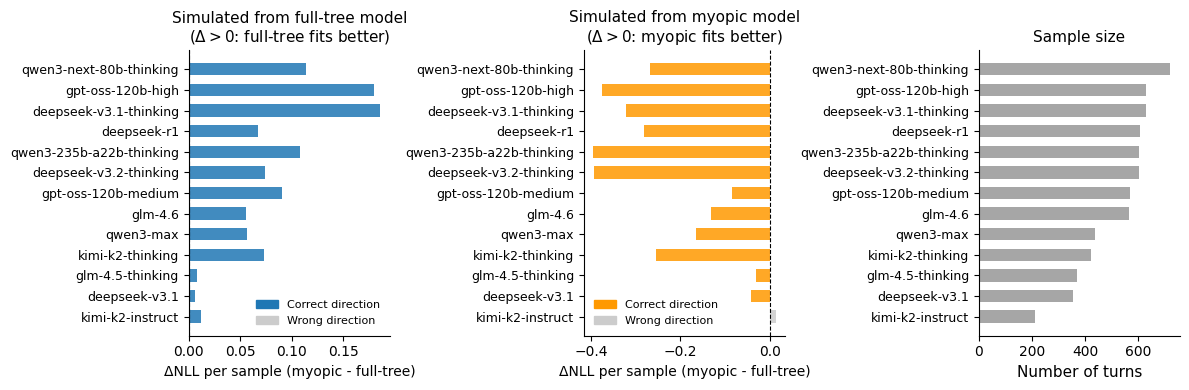

In [4]:
COLOR_FULL   = '#1f77b4'   # blue
COLOR_MYOPIC = '#ff9900'   # orange
COLOR_FAIL   = '#cccccc'   # grey — wrong direction

def recovery_bar(ax, values, short_names, expected_positive, color, title, order):
    df_plot = pd.DataFrame({'val': values, 'name': short_names})
    df_plot = df_plot.set_index('name').reindex(order).reset_index()
    n = len(df_plot)
    y = np.arange(n)
    colors = [color if (v > 0) == expected_positive else COLOR_FAIL
              for v in df_plot['val']]
    ax.barh(y, df_plot['val'], height=0.6, color=colors, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot['name'], fontsize=9)
    ax.set_xlabel('ΔNLL per sample (myopic - full-tree)', fontsize=10)
    ax.set_title(title, fontsize=11)
    n_ok = sum((v > 0) == expected_positive for v in df_plot['val'])
    patch_ok   = mpatches.Patch(color=color,      label=f'Correct direction')
    patch_fail = mpatches.Patch(color=COLOR_FAIL, label='Wrong direction')
    ax.legend(handles=[patch_ok, patch_fail], fontsize=8, frameon=False)

# Shared order: sorted by N ascending
order = df.sort_values('N', ascending=True)['short_name'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

recovery_bar(
    axes[0],
    df['delta_full'].values, df['short_name'].values,
    expected_positive=True, color=COLOR_FULL,
    title='Simulated from full-tree model\n($\Delta > 0$: full-tree fits better)',
    order=order,
)

recovery_bar(
    axes[1],
    df['delta_myopic'].values, df['short_name'].values,
    expected_positive=False, color=COLOR_MYOPIC,
    title='Simulated from myopic model\n($\Delta > 0$: myopic fits better)',
    order=order,
)

# Panel 3: N turns
df_n = df.set_index('short_name')['N'].reindex(order)
y = np.arange(len(df_n))
axes[2].barh(y, df_n.values, height=0.6, color='#888888', alpha=0.75)
axes[2].set_yticks(y)
axes[2].set_yticklabels(df_n.index, fontsize=9)
axes[2].set_xlabel('Number of turns', fontsize=11)
axes[2].set_title('Sample size', fontsize=11)

plt.tight_layout()
plt.savefig('figures/model_recovery.pdf', bbox_inches='tight')
plt.show()